<a href="https://colab.research.google.com/github/tomasrojas88/Data_Science_1/blob/main/TP_Final_NLP_DeepLearning_Tomas_Rojas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final - Data Science III: NLP & Deep Learning

Alumno: Tomás Rojas

Comisión: 90480

## 1. Introducción

En este proyecto se trabaja con técnicas de Procesamiento de Lenguaje Natural (NLP) y modelos de clasificación aplicados a comentarios de clientes vinculados al servicio de una compañía de seguros.

El dataset utilizado contiene un identificador de registro, una variable de puntaje otorgado por el cliente y un comentario abierto. A partir de esta información, el objetivo fue analizar el contenido textual de las opiniones, identificar patrones frecuentes en los comentarios y construir modelos capaces de clasificar automáticamente la valoración del cliente a partir del texto.

El desarrollo del trabajo se organizó en dos etapas principales. En una primera instancia se realizó el preprocesamiento y análisis exploratorio del texto, incluyendo limpieza, eliminación de stopwords, análisis de frecuencia de palabras y bigramas, visualizaciones y una prueba complementaria de análisis de sentimiento. En una segunda etapa, se vectorizaron los comentarios mediante TF-IDF y se entrenaron distintos modelos de clasificación supervisada para comparar su desempeño.

## 2. Objetivo del proyecto

El objetivo general del proyecto fue aplicar técnicas de NLP sobre comentarios de clientes para extraer información relevante del contenido textual y, posteriormente, construir modelos de clasificación capaces de predecir si un comentario se asocia a una valoración positiva o negativa.

De manera específica, se buscó preparar y limpiar los textos, explorar las palabras y combinaciones más frecuentes, representar los comentarios en formato numérico mediante TF-IDF y comparar distintos algoritmos de clasificación. Además, se procuró identificar cuál de los modelos evaluados ofrecía el mejor equilibrio de desempeño, especialmente considerando que el dataset presentaba una distribución desbalanceada entre clases.

## 3. Descripción del dataset


El dataset utilizado en este proyecto contiene información proveniente de respuestas de clientes e incluye tres variables principales: un identificador único (`ID`), un puntaje otorgado por el cliente (`Puntaje`) y un comentario abierto (`Comentario`).

La variable `Puntaje` presenta valores en una escala de 0 a 10, lo que permite abordar el problema desde la lógica de NPS. A partir de esta variable, se construyó una etiqueta binaria para clasificación: se consideraron positivos los puntajes 9 y 10, negativos los puntajes de 0 a 6, y se excluyeron los valores 7 y 8 por corresponder a casos pasivos o intermedios.

Por su parte, la columna `Comentario` constituye la fuente principal para el análisis de lenguaje natural, ya que contiene opiniones textuales de los clientes sobre su experiencia con el servicio.

## 4. Carga y exploración inicial de los datos

En esta etapa se realizó la carga del dataset y una primera exploración de su estructura general. Para ello, se verificaron las primeras filas de la base, la cantidad de registros y variables, los tipos de datos de cada columna, la presencia de valores nulos y la distribución de la variable `Puntaje`.

Esta revisión inicial permitió confirmar que el dataset contiene tres variables principales (`ID`, `Puntaje` y `Comentario`) y que una parte de los registros no presenta comentario asociado. También se observó que la distribución de puntajes está fuertemente concentrada en valores altos, lo cual resulta consistente con un esquema de respuestas tipo NPS.

In [ ]:
# Importo pandas para trabajar con el dataset
import pandas as pd

# Defino la URL del archivo Excel subido a GitHub
url = "https://github.com/tomasrojas88/Data_Science_1/raw/main/Base%20de%20datos%20CURSO%20NPS.xlsx"

# Cargo el archivo Excel desde GitHub
df = pd.read_excel(url)

# Muestro las primeras filas para verificar que la carga sea correcta
df.head()

,ID,Puntaje,Comentario
0,1,10,"Porque cuando tuve un accidente ,me solucionar..."
1,2,7,NaN
2,3,10,"Porque desde que la uso no tuve problemas, ade..."
3,4,9,Porque la aseguradora tiene lo que necesito y ...
4,5,8,Porque AFORTUNADAMENTE no tuve un siniestro y ...


In [ ]:
# Reviso la cantidad de filas y columnas del dataset
print("Dimensiones del dataset:", df.shape)

# Veo los nombres de las columnas para confirmar su estructura
print("Columnas:", df.columns.tolist())

# Verifico tipos de datos y valores nulos
df.info()

# Cuento los valores faltantes por columna
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Reviso cómo se distribuyen los puntajes
print("\nDistribución de la variable Puntaje:")
print(df["Puntaje"].value_counts().sort_index())

Dimensiones del dataset: (5645, 3)
Columnas: ['ID', 'Puntaje', 'Comentario']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5645 entries, 0 to 5644
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID          5645 non-null   int64 
 1   Puntaje     5645 non-null   int64 
 2   Comentario  4008 non-null   object
dtypes: int64(2), object(1)
memory usage: 132.4+ KB

Valores nulos por columna:
ID               0
Puntaje          0
Comentario    1637
dtype: int64

Distribución de la variable Puntaje:
Puntaje
0       61
1       17
2       16
3       26
4       46
5      218
6      123
7      353
8      748
9      763
10    3274
Name: count, dtype: int64


## 5. Preparación de los datos para NLP

En esta etapa se realizó la preparación de los datos para el análisis de lenguaje natural. En primer lugar, se eliminaron los registros que no contenían comentarios, ya que no aportaban información útil para el procesamiento de texto. Luego, a partir de la variable `Puntaje`, se construyó una variable objetivo binaria, considerando como positivos los puntajes 9 y 10 y como negativos los puntajes de 0 a 6. Los valores 7 y 8 fueron excluidos por corresponder a casos intermedios o pasivos.

Posteriormente, se aplicó una limpieza básica sobre los comentarios, que incluyó conversión a minúsculas, normalización de caracteres, eliminación de signos de puntuación y espacios innecesarios. Finalmente, se eliminaron stopwords en español con el objetivo de conservar principalmente las palabras con mayor carga semántica para el análisis posterior.

In [ ]:
# Elimino los registros sin comentario porque no sirven para el análisis de texto
df_nlp = df.dropna(subset=["Comentario"]).copy()

# Verifico cuántos registros quedan después de quitar los comentarios nulos
print("Dimensiones del dataset para NLP:", df_nlp.shape)

# Reviso nuevamente los valores nulos
print("\nValores nulos en la nueva base:")
print(df_nlp.isnull().sum())

# Muestro las primeras filas de la nueva base
df_nlp.head()

Dimensiones del dataset para NLP: (4008, 3)

Valores nulos en la nueva base:
ID            0
Puntaje       0
Comentario    0
dtype: int64


,ID,Puntaje,Comentario
0,1,10,"Porque cuando tuve un accidente ,me solucionar..."
2,3,10,"Porque desde que la uso no tuve problemas, ade..."
3,4,9,Porque la aseguradora tiene lo que necesito y ...
4,5,8,Porque AFORTUNADAMENTE no tuve un siniestro y ...
5,6,8,por satisfaccion


In [ ]:
# Creo una función para transformar el puntaje NPS en una variable binaria
def clasificar_sentimiento_nps(puntaje):
    # Considero positivos a los promotores (9 y 10)
    if puntaje >= 9:
        return 1
    # Considero negativos a los detractores (0 a 6)
    elif puntaje <= 6:
        return 0
    # Dejo como nulos a los pasivos (7 y 8) para excluirlos del modelo
    else:
        return None

# Aplico la transformación sobre la columna Puntaje
df_nlp["target"] = df_nlp["Puntaje"].apply(clasificar_sentimiento_nps)

# Reviso la distribución inicial de la nueva variable objetivo
print("Distribución inicial de target:")
print(df_nlp["target"].value_counts(dropna=False))

Distribución inicial de target:
target
1.0    2979
NaN     675
0.0     354
Name: count, dtype: int64


In [ ]:
# Elimino los casos pasivos porque no los voy a usar en la clasificación binaria
df_modelo = df_nlp.dropna(subset=["target"]).copy()

# Convierto la variable objetivo a entero
df_modelo["target"] = df_modelo["target"].astype(int)

# Verifico cuántos registros quedan para modelar
print("Dimensiones de la base para modelado:", df_modelo.shape)

# Reviso la distribución final de la variable objetivo
print("\nDistribución final de target:")
print(df_modelo["target"].value_counts())

# Muestro algunas filas para controlar el resultado
df_modelo[["Puntaje", "Comentario", "target"]].head()

Dimensiones de la base para modelado: (3333, 4)

Distribución final de target:
target
1    2979
0     354
Name: count, dtype: int64


,Puntaje,Comentario,target
0,10,"Porque cuando tuve un accidente ,me solucionar...",1
2,10,"Porque desde que la uso no tuve problemas, ade...",1
3,9,Porque la aseguradora tiene lo que necesito y ...,1
6,9,"Por el asesor de seguros de mi zona, me gusta ...",1
8,10,"Buen servicio, aunque aún no he necesitado que...",1


In [ ]:
# Importo la librería re para hacer limpieza básica de texto
import re

# Creo una función para limpiar los comentarios y dejar solo texto útil
def limpiar_texto(texto):
    # Asegurarse de que el input sea un string
    texto = str(texto)
    # Convierto el texto a minúsculas para unificar palabras
    texto = texto.lower()

    # Elimino tildes simples reemplazando vocales acentuadas
    texto = texto.replace("á", "a").replace("é", "e").replace("í", "i").replace("ó", "o").replace("ú", "u")

    # Elimino signos de puntuación y caracteres especiales
    texto = re.sub(r"[^a-zA-ZñÑ\s]", " ", texto)

    # Elimino espacios repetidos
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto

# Aplico la limpieza sobre la columna de comentarios
df_modelo["comentario_limpio"] = df_modelo["Comentario"].apply(limpiar_texto)

# Muestro ejemplos para comparar comentario original y comentario limpio
df_modelo[["Comentario", "comentario_limpio"]].head(10)

,Comentario,comentario_limpio
0,"Porque cuando tuve un accidente ,me solucionar...",porque cuando tuve un accidente me solucionaro...
2,"Porque desde que la uso no tuve problemas, ade...",porque desde que la uso no tuve problemas adem...
3,Porque la aseguradora tiene lo que necesito y ...,porque la aseguradora tiene lo que necesito y ...
6,"Por el asesor de seguros de mi zona, me gusta ...",por el asesor de seguros de mi zona me gusta l...
8,"Buen servicio, aunque aún no he necesitado que...",buen servicio aunque aun no he necesitado que ...
9,Asé 70 años que tengo seguro con ustedes,ase años que tengo seguro con ustedes
10,"Estoy satisfecho con el servicio, pero me resu...",estoy satisfecho con el servicio pero me resul...
11,Es muy recomendable,es muy recomendable
12,"Muy satisfecho por la promotora, que siempre e...",muy satisfecho por la promotora que siempre es...
13,Porque es lo que me parece,porque es lo que me parece


In [ ]:
# Importo nltk y descargo las stopwords en español
import nltk
from nltk.corpus import stopwords

# Descargo el recurso de stopwords para poder usarlo en el análisis
nltk.download("stopwords")

# Guardo las stopwords en español en una lista para filtrar palabras sin contenido semántico fuerte
stop_words = set(stopwords.words("spanish"))

# Creo una función para eliminar stopwords del texto ya limpio
def eliminar_stopwords(texto):
    # Separo el texto en palabras
    palabras = texto.split()

    # Conservo solo las palabras que no están en la lista de stopwords
    palabras_filtradas = [palabra for palabra in palabras if palabra not in stop_words]

    # Vuelvo a unir las palabras en un solo texto
    return " ".join(palabras_filtradas)

# Aplico la eliminación de stopwords sobre la columna de texto limpio
df_modelo["comentario_sin_stopwords"] = df_modelo["comentario_limpio"].apply(eliminar_stopwords)

# Comparo el texto limpio con la nueva versión sin stopwords
df_modelo[["comentario_limpio", "comentario_sin_stopwords"]].head(10)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,comentario_limpio,comentario_sin_stopwords
0,porque cuando tuve un accidente me solucionaro...,accidente solucionaron rapidamente
2,porque desde que la uso no tuve problemas adem...,uso problemas ademas facil gestionar
3,porque la aseguradora tiene lo que necesito y ...,aseguradora necesito mas hno gracias tambien a...
6,por el asesor de seguros de mi zona me gusta l...,asesor seguros zona gusta atencion personaliza...
8,buen servicio aunque aun no he necesitado que ...,buen servicio aunque aun necesitado paguen
9,ase años que tengo seguro con ustedes,ase años seguro ustedes
10,estoy satisfecho con el servicio pero me resul...,satisfecho servicio resulta dificil costear cu...
11,es muy recomendable,recomendable
12,muy satisfecho por la promotora que siempre es...,satisfecho promotora siempre atenta posibles p...
13,porque es lo que me parece,parece


## 6. Análisis exploratorio del texto

En esta sección se desarrolló un análisis exploratorio del corpus textual una vez finalizada la etapa de preparación. El objetivo fue identificar los términos más frecuentes, visualizar patrones recurrentes en los comentarios y detectar combinaciones de palabras con sentido relevante para el negocio.

Para ello, se analizaron frecuencias simples, visualizaciones gráficas, bigramas, una nube de palabras y un análisis de sentimiento complementario. Esta etapa permitió obtener una primera interpretación del contenido de los comentarios antes de avanzar hacia la vectorización y el modelado supervisado.

### 6.1 Palabras más frecuentes

En primer lugar, se analizaron las palabras más frecuentes presentes en los comentarios una vez aplicado el preprocesamiento del texto. Este paso permitió identificar los términos que aparecen con mayor recurrencia en el corpus y obtener una primera aproximación a los temas más mencionados por los clientes.

In [ ]:
# Importo Counter para contar la frecuencia de las palabras
from collections import Counter

# Uno todos los comentarios procesados en un solo texto
texto_completo = " ".join(df_modelo["comentario_sin_stopwords"])

# Separo el texto en palabras individuales
palabras = texto_completo.split()

# Cuento cuántas veces aparece cada palabra
frecuencia_palabras = Counter(palabras)

# Muestro las 20 palabras más frecuentes
print("Palabras más frecuentes en los comentarios:")
print(frecuencia_palabras.most_common(20))

Palabras más frecuentes en los comentarios:
[('seguro', 372), ('siempre', 370), ('atencion', 359), ('buena', 315), ('servicio', 310), ('rus', 219), ('nunca', 197), ('precio', 167), ('conforme', 163), ('excelente', 156), ('problemas', 151), ('buen', 149), ('compañia', 149), ('empresa', 135), ('problema', 135), ('respuesta', 125), ('bien', 120), ('confianza', 118), ('momento', 114), ('años', 111)]


In [ ]:
# Convierto las palabras más frecuentes en un DataFrame para verlas mejor
top_20_palabras = pd.DataFrame(frecuencia_palabras.most_common(20), columns=["palabra", "frecuencia"])

# Muestro la tabla con las 20 palabras más repetidas
top_20_palabras

,palabra,frecuencia
0,seguro,372
1,siempre,370
2,atencion,359
3,buena,315
4,servicio,310
5,rus,219
6,nunca,197
7,precio,167
8,conforme,163
9,excelente,156


### 6.2 Visualización de frecuencias

Con el fin de facilitar la interpretación de las frecuencias observadas, se construyó un gráfico de barras con las palabras más repetidas. Esta visualización permite detectar de forma más clara cuáles son los términos dominantes en los comentarios analizados.

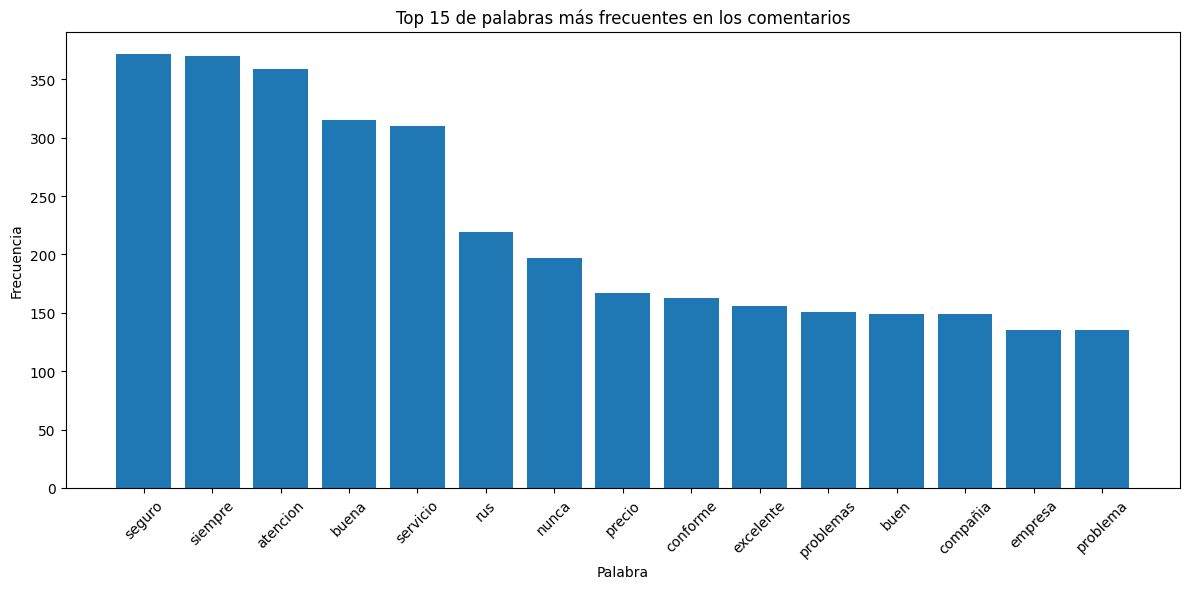

In [ ]:
# Importo matplotlib para graficar las palabras más frecuentes
import matplotlib.pyplot as plt

# Selecciono las 15 palabras más frecuentes para el gráfico
top_15_palabras = top_20_palabras.head(15)

# Creo un gráfico de barras para visualizar las palabras más repetidas
plt.figure(figsize=(12,6))
plt.bar(top_15_palabras["palabra"], top_15_palabras["frecuencia"])

# Agrego título y nombres de ejes para que el gráfico sea interpretable
plt.title("Top 15 de palabras más frecuentes en los comentarios")
plt.xlabel("Palabra")
plt.ylabel("Frecuencia")

# Giro las etiquetas del eje x para mejorar la lectura
plt.xticks(rotation=45)

# Ajusto el diseño para que no se superpongan elementos
plt.tight_layout()

# Muestro el gráfico final
plt.show()

### 6.3 Bigramas más frecuentes

Además del análisis de palabras individuales, se estudiaron los bigramas más frecuentes, es decir, combinaciones de dos palabras consecutivas. Este enfoque aporta mayor contexto que el conteo aislado de términos y permite detectar expresiones más representativas del discurso de los clientes.

In [ ]:
# Importo CountVectorizer para extraer bigramas frecuentes del texto
from sklearn.feature_extraction.text import CountVectorizer

# Configuro el vectorizador para obtener bigramas a partir de los comentarios procesados
vectorizer_bigramas = CountVectorizer(ngram_range=(2,2))

# Ajusto el vectorizador sobre la columna de texto sin stopwords
X_bigramas = vectorizer_bigramas.fit_transform(df_modelo["comentario_sin_stopwords"])

# Obtengo la lista de bigramas detectados
bigramas = vectorizer_bigramas.get_feature_names_out()

# Sumo la frecuencia total de aparición de cada bigrama
frecuencias_bigramas = X_bigramas.sum(axis=0).A1

# Creo un DataFrame con los bigramas y su frecuencia
df_bigramas = pd.DataFrame({
    "bigrama": bigramas,
    "frecuencia": frecuencias_bigramas
})

# Ordeno los bigramas de mayor a menor frecuencia
df_bigramas = df_bigramas.sort_values(by="frecuencia", ascending=False)

# Muestro los 20 bigramas más frecuentes
df_bigramas.head(20)

,bigrama,frecuencia
1444,buena atencion,121
1434,buen servicio,61
7631,relacion precio,52
6631,precio calidad,46
4464,hace años,43
1432,buen seguro,41
5839,nunca problemas,41
5726,ningun problema,41
2370,conforme servicio,39
5723,ningun inconveniente,32


### 6.4 Nube de palabras

Como complemento visual del análisis exploratorio, se generó una nube de palabras a partir de los comentarios procesados. Esta representación permite observar de manera rápida los términos con mayor presencia relativa dentro del corpus textual.

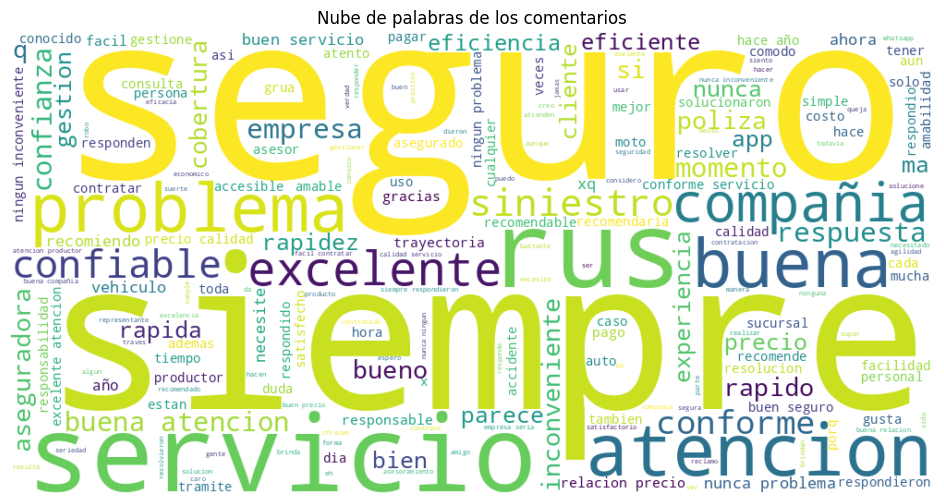

In [ ]:
# Importo la librería WordCloud para generar una nube de palabras
from wordcloud import WordCloud

# Uno todos los comentarios procesados en un solo texto
texto_nube = " ".join(df_modelo["comentario_sin_stopwords"])

# Genero la nube de palabras con los términos más frecuentes del corpus
wordcloud = WordCloud(width=1000, height=500, background_color="white").generate(texto_nube)

# Grafico la nube de palabras para visualizar los términos más repetidos
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras de los comentarios")
plt.show()

### 6.5 Análisis de sentimiento

Por último, se realizó una prueba complementaria de análisis de sentimiento sobre los comentarios limpios. El objetivo fue explorar si la polaridad del texto podía aportar una señal adicional para interpretar el corpus.

Sin embargo, los resultados obtenidos fueron limitados, ya que la herramienta utilizada concentró una gran parte de los comentarios en valores de polaridad neutra. Esto sugiere que, para este tipo de comentarios en español y dentro de este dominio específico, el análisis de sentimiento implementado no resulta suficientemente robusto como para ser considerado una técnica central del proyecto. Por este motivo, su uso se mantuvo como un recurso exploratorio y complementario.

In [ ]:
# Importo TextBlob para hacer un análisis de sentimiento simple
from textblob import TextBlob

# Creo una función para calcular la polaridad del comentario
def obtener_polaridad(texto):
    # Convierto el texto en un objeto TextBlob
    blob = TextBlob(texto)

    # Devuelvo la polaridad del texto en un rango de -1 a 1
    return blob.sentiment.polarity

# Aplico el análisis de sentimiento sobre los comentarios limpios
df_modelo["polaridad"] = df_modelo["comentario_limpio"].apply(obtener_polaridad)

# Muestro algunas filas para revisar el resultado
df_modelo[["comentario_limpio", "polaridad"]].head(10)

,comentario_limpio,polaridad
0,porque cuando tuve un accidente me solucionaro...,0.0
2,porque desde que la uso no tuve problemas adem...,0.0
3,porque la aseguradora tiene lo que necesito y ...,0.0
6,por el asesor de seguros de mi zona me gusta l...,0.0
8,buen servicio aunque aun no he necesitado que ...,0.0
9,ase años que tengo seguro con ustedes,0.0
10,estoy satisfecho con el servicio pero me resul...,0.0
11,es muy recomendable,0.0
12,muy satisfecho por la promotora que siempre es...,0.0
13,porque es lo que me parece,0.0


In [ ]:
# Describo estadísticamente los valores de polaridad obtenidos
df_modelo["polaridad"].describe()

,polaridad
count,3333.000000
mean,0.004637
std,0.051668
min,-0.800000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.700000


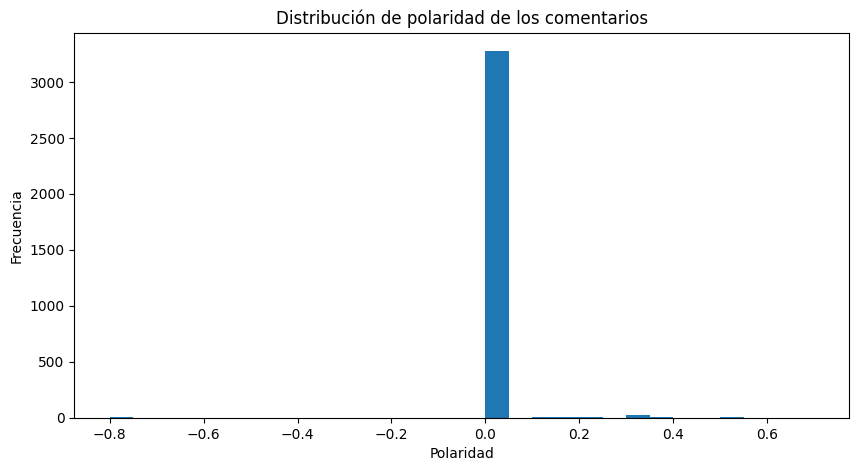

In [ ]:
# Grafico la distribución de polaridad para observar cómo se reparten los sentimientos detectados
plt.figure(figsize=(10,5))
plt.hist(df_modelo["polaridad"], bins=30)

# Agrego título y nombres de ejes para interpretar el gráfico
plt.title("Distribución de polaridad de los comentarios")
plt.xlabel("Polaridad")
plt.ylabel("Frecuencia")

# Muestro el gráfico final
plt.show()

### 6.6 Hallazgos de negocio a partir de los comentarios

A partir del análisis de frecuencias, bigramas y términos más representativos del corpus, es posible extraer una primera lectura de negocio sobre los aspectos más presentes en la voz del cliente.

En los comentarios se observa una fuerte presencia de términos vinculados con la atención, el servicio, la confianza y la respuesta de la compañía. Asimismo, entre los bigramas más frecuentes aparecen expresiones como “buena atención”, “buen servicio”, “excelente atención” y “precio calidad”, lo que sugiere que las valoraciones positivas están estrechamente relacionadas con la experiencia de atención y con la percepción de valor del servicio recibido.

Por otro lado, entre los términos más asociados a comentarios negativos aparecen referencias como “siniestro”, “mala”, “falta”, “todavía” y “cuota”. Esto permite inferir que parte de las experiencias desfavorables podría estar asociada a demoras, problemas en la gestión o disconformidades económicas. En conjunto, los comentarios muestran que los clientes no solo evalúan el producto, sino también la calidad de atención, la rapidez de respuesta y la experiencia general con la compañía.

## 7. Vectorización del texto con TF-IDF

En esta etapa se realizó la vectorización del texto mediante la técnica TF-IDF (Term Frequency - Inverse Document Frequency), con el objetivo de transformar los comentarios procesados en una representación numérica utilizable por los modelos de aprendizaje automático.

Esta técnica permite asignar mayor peso a las palabras más relevantes dentro de cada comentario y menor peso a aquellas que aparecen con mucha frecuencia en todo el corpus. A partir de esta transformación, se construyó la matriz de entrada para los modelos de clasificación supervisada.

In [ ]:
# Importo TfidfVectorizer para convertir el texto en variables numéricas
from sklearn.feature_extraction.text import TfidfVectorizer

# Defino el vectorizador TF-IDF para representar los comentarios según la importancia de sus palabras
tfidf = TfidfVectorizer(max_features=1000)

# Transformo la columna de texto procesado en una matriz numérica
X = tfidf.fit_transform(df_modelo["comentario_sin_stopwords"])

# Defino la variable objetivo para la clasificación
y = df_modelo["target"]

# Verifico la forma de la matriz de entrada y de la variable objetivo
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (3333, 1000)
Dimensiones de y: (3333,)


In [ ]:
# Muestro algunas palabras del vocabulario generado por TF-IDF
print("Primeros términos del vocabulario TF-IDF:")
print(tfidf.get_feature_names_out()[:20])

Primeros términos del vocabulario TF-IDF:
['abogado' 'abonar' 'abuelo' 'accesible' 'accesibles' 'acceso' 'accidente'
 'accidentes' 'acompañado' 'acompañamiento' 'acordado' 'acorde' 'acordes'
 'actua' 'actualizacion' 'acuerdo' 'adecuada' 'ademas' 'adquirir'
 'agencia']


## 8. Construcción de modelos de clasificación

En esta etapa se desarrollaron distintos modelos de clasificación supervisada con el objetivo de predecir si un comentario corresponde a una valoración positiva o negativa a partir de su contenido textual.

Para ello, primero se separó la base en conjuntos de entrenamiento y prueba, manteniendo la proporción de clases mediante una partición estratificada. Luego se entrenaron y evaluaron tres enfoques diferentes: Regresión Logística, Naive Bayes y una Red Neuronal MLP. Finalmente, se comparó el desempeño de los modelos considerando no solo la accuracy general, sino también métricas específicas por clase, debido al desbalance presente en el dataset.

### 8.1 Separación en entrenamiento y prueba

Antes de entrenar los modelos, se separaron los datos en conjuntos de entrenamiento y prueba. Esta división permite entrenar los algoritmos sobre una parte del dataset y evaluar su desempeño sobre datos no vistos previamente.

Dado que la variable objetivo presenta un desbalance entre clases, se utilizó una partición estratificada para conservar aproximadamente la misma proporción de comentarios positivos y negativos en ambos conjuntos.

In [ ]:
# Importo train_test_split para separar los datos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Separo los datos en entrenamiento y prueba manteniendo la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Verifico las dimensiones de cada conjunto
print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

Dimensiones de X_train: (2666, 1000)
Dimensiones de X_test: (667, 1000)
Dimensiones de y_train: (2666,)
Dimensiones de y_test: (667,)


In [ ]:
# Reviso la distribución de clases en entrenamiento y prueba
print("Distribución de clases en y_train:")
print(y_train.value_counts(normalize=True))

print("\nDistribución de clases en y_test:")
print(y_test.value_counts(normalize=True))

Distribución de clases en y_train:
target
1    0.893848
0    0.106152
Name: proportion, dtype: float64

Distribución de clases en y_test:
target
1    0.893553
0    0.106447
Name: proportion, dtype: float64


### 8.2 Modelo de Regresión Logística

Como primer modelo se utilizó Regresión Logística, una técnica ampliamente aplicada en tareas de clasificación de texto. En este caso, además, se configuró el parámetro `class_weight="balanced"` para compensar parcialmente el desbalance entre las clases.

Este modelo fue considerado como la alternativa principal del proyecto, ya que mostró el desempeño más equilibrado entre ambas clases y una mejor capacidad para detectar comentarios negativos sin perder demasiada precisión sobre la clase positiva.

In [ ]:
# Importo el modelo de Regresión Logística para la clasificación
from sklearn.linear_model import LogisticRegression

# Creo el modelo usando class_weight='balanced' para compensar el desbalance entre clases
modelo_lr = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)

# Entreno el modelo con los datos de entrenamiento
modelo_lr.fit(X_train, y_train)

# Genero las predicciones sobre el conjunto de prueba
y_pred = modelo_lr.predict(X_test)

# Muestro las primeras predicciones para verificar que el modelo haya corrido
print("Primeras predicciones del modelo:")
print(y_pred[:20])

Primeras predicciones del modelo:
[1 1 1 0 1 0 1 1 0 0 1 1 1 0 0 1 0 1 1 1]


In [ ]:
# Importo métricas para evaluar el rendimiento del modelo de clasificación
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calculo la accuracy general del modelo
accuracy = accuracy_score(y_test, y_pred)

# Muestro la accuracy del modelo
print("Accuracy del modelo:", accuracy)

# Muestro el reporte de clasificación con precision, recall y f1-score
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

# Muestro la matriz de confusión para ver aciertos y errores por clase
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

Accuracy del modelo: 0.8470764617691154

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.39      0.75      0.51        71
           1       0.97      0.86      0.91       596

    accuracy                           0.85       667
   macro avg       0.68      0.80      0.71       667
weighted avg       0.90      0.85      0.87       667

Matriz de confusión:
[[ 53  18]
 [ 84 512]]


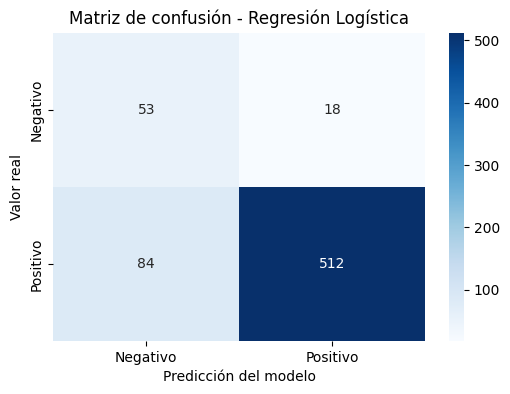

In [ ]:
# Importo seaborn y matplotlib para graficar la matriz de confusión
import seaborn as sns
import matplotlib.pyplot as plt

# Calculo la matriz de confusión del modelo
matriz_confusion = confusion_matrix(y_test, y_pred)

# Grafico la matriz de confusión para visualizar aciertos y errores del modelo
plt.figure(figsize=(6,4))
sns.heatmap(matriz_confusion, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negativo", "Positivo"],
            yticklabels=["Negativo", "Positivo"])

# Agrego título y nombres de ejes para interpretar mejor el gráfico
plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción del modelo")
plt.ylabel("Valor real")

# Muestro el gráfico final
plt.show()

In [ ]:
# Obtengo los nombres de las palabras usadas por el vectorizador TF-IDF
feature_names = tfidf.get_feature_names_out()

# Extraigo los coeficientes del modelo para interpretar qué palabras pesan más
coeficientes = modelo_lr.coef_[0]

# Creo un DataFrame con cada palabra y su peso en la clasificación
df_coeficientes = pd.DataFrame({
    "palabra": feature_names,
    "coeficiente": coeficientes
})

# Ordeno de menor a mayor para identificar palabras asociadas a comentarios negativos
top_negativas = df_coeficientes.sort_values(by="coeficiente").head(15)

# Ordeno de mayor a menor para identificar palabras asociadas a comentarios positivos
top_positivas = df_coeficientes.sort_values(by="coeficiente", ascending=False).head(15)

# Muestro las palabras más asociadas a la clase negativa
print("Palabras más asociadas a comentarios negativos:")
print(top_negativas)

# Muestro las palabras más asociadas a la clase positiva
print("\nPalabras más asociadas a comentarios positivos:")
print(top_positivas)

Palabras más asociadas a comentarios negativos:
         palabra  coeficiente
154         caro    -3.536310
873    siniestro    -2.666850
754   recomendar    -2.628248
500         mala    -2.395159
102          aun    -2.199197
929      todavia    -2.196056
117         baja    -2.170922
499          mal    -2.106996
402        falta    -2.090776
607     personal    -1.893635
152         cara    -1.838564
273        cuota    -1.818580
318        dicen    -1.690903
769  referencias    -1.634544
188    compañias    -1.610953

Palabras más asociadas a comentarios positivos:
            palabra  coeficiente
861         siempre     3.890943
134           buena     3.655120
207        conforme     3.172581
390       excelente     3.028220
205       confianza     2.651071
203       confiable     2.612945
723          rapido     2.470874
187        compañia     2.390109
90         atencion     2.374172
467  inconvenientes     2.290399
679        problema     2.236387
123            bien     2.0

### 8.3 Modelo Naive Bayes

Como segundo enfoque se evaluó un modelo Multinomial Naive Bayes, un algoritmo clásico en problemas de clasificación de texto debido a su simpleza computacional y buen rendimiento en representaciones tipo bolsa de palabras o TF-IDF.

Su incorporación en este proyecto tuvo como objetivo comparar el desempeño de un modelo probabilístico tradicional frente a la Regresión Logística.

In [ ]:
# Importo Multinomial Naive Bayes para comparar su rendimiento con Regresión Logística
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Creo el modelo Naive Bayes para clasificación de texto
modelo_nb = MultinomialNB()

# Entreno el modelo con los datos de entrenamiento
modelo_nb.fit(X_train, y_train)

# Genero predicciones sobre el conjunto de prueba
y_pred_nb = modelo_nb.predict(X_test)

# Calculo y muestro la accuracy del modelo
print("Accuracy de Naive Bayes:", accuracy_score(y_test, y_pred_nb))

# Muestro el reporte de clasificación para evaluar precision, recall y f1-score
print("\nReporte de clasificación - Naive Bayes:")
print(classification_report(y_test, y_pred_nb))

# Muestro la matriz de confusión para analizar aciertos y errores
print("Matriz de confusión - Naive Bayes:")
print(confusion_matrix(y_test, y_pred_nb))

Accuracy de Naive Bayes: 0.9070464767616192

Reporte de clasificación - Naive Bayes:
              precision    recall  f1-score   support

           0       0.85      0.15      0.26        71
           1       0.91      1.00      0.95       596

    accuracy                           0.91       667
   macro avg       0.88      0.58      0.61       667
weighted avg       0.90      0.91      0.88       667

Matriz de confusión - Naive Bayes:
[[ 11  60]
 [  2 594]]


### 8.4 Modelo de Red Neuronal MLP

Finalmente, se incorporó una Red Neuronal MLP (Multi-Layer Perceptron) con una capa oculta, con el fin de incluir un enfoque vinculado al aprendizaje profundo dentro del proyecto.

Si bien esta arquitectura es simple en comparación con modelos más avanzados de deep learning, su utilización permite extender el análisis hacia una alternativa no lineal y comparar su comportamiento frente a los modelos clásicos.

In [ ]:
# Importo MLPClassifier para probar una red neuronal simple de clasificación
from sklearn.neural_network import MLPClassifier

# Creo una red neuronal simple con una capa oculta de 100 neuronas
modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=300,
    random_state=42
)

# Entreno la red neuronal con los datos de entrenamiento
modelo_mlp.fit(X_train, y_train)

# Genero predicciones sobre el conjunto de prueba
y_pred_mlp = modelo_mlp.predict(X_test)

# Muestro la accuracy del modelo para una primera comparación
print("Accuracy de la red neuronal (MLP):", accuracy_score(y_test, y_pred_mlp))

# Muestro el reporte de clasificación para evaluar precision, recall y f1-score
print("\nReporte de clasificación - Red Neuronal (MLP):")
print(classification_report(y_test, y_pred_mlp))

# Muestro la matriz de confusión para analizar aciertos y errores
print("Matriz de confusión - Red Neuronal (MLP):")
print(confusion_matrix(y_test, y_pred_mlp))

Accuracy de la red neuronal (MLP): 0.8950524737631185

Reporte de clasificación - Red Neuronal (MLP):
              precision    recall  f1-score   support

           0       0.51      0.28      0.36        71
           1       0.92      0.97      0.94       596

    accuracy                           0.90       667
   macro avg       0.72      0.62      0.65       667
weighted avg       0.88      0.90      0.88       667

Matriz de confusión - Red Neuronal (MLP):
[[ 20  51]
 [ 19 577]]


### 8.5 Comparación de modelos

Una vez entrenados los tres modelos, se realizó una comparación conjunta de sus principales métricas de desempeño. Dado que el dataset presenta una clara desproporción entre comentarios positivos y negativos, la comparación no se centró únicamente en la accuracy global, sino también en la capacidad de cada modelo para detectar correctamente la clase minoritaria.

Este análisis permitió seleccionar el modelo más adecuado para el problema planteado.

In [ ]:
# Creo una tabla comparativa entre los tres modelos evaluados
comparacion_modelos = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Naive Bayes", "Red Neuronal MLP"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_mlp)
    ],
    "Precision clase 0": [
        precision_score(y_test, y_pred, pos_label=0),
        precision_score(y_test, y_pred_nb, pos_label=0),
        precision_score(y_test, y_pred_mlp, pos_label=0)
    ],
    "Recall clase 0": [
        recall_score(y_test, y_pred, pos_label=0),
        recall_score(y_test, y_pred_nb, pos_label=0),
        recall_score(y_test, y_pred_mlp, pos_label=0)
    ],
    "F1 clase 0": [
        f1_score(y_test, y_pred, pos_label=0),
        f1_score(y_test, y_pred_nb, pos_label=0),
        f1_score(y_test, y_pred_mlp, pos_label=0)
    ],
    "Precision clase 1": [
        precision_score(y_test, y_pred, pos_label=1),
        precision_score(y_test, y_pred_nb, pos_label=1),
        precision_score(y_test, y_pred_mlp, pos_label=1)
    ],
    "Recall clase 1": [
        recall_score(y_test, y_pred, pos_label=1),
        recall_score(y_test, y_pred_nb, pos_label=1),
        recall_score(y_test, y_pred_mlp, pos_label=1)
    ],
    "F1 clase 1": [
        f1_score(y_test, y_pred, pos_label=1),
        f1_score(y_test, y_pred_nb, pos_label=1),
        f1_score(y_test, y_pred_mlp, pos_label=1)
    ]
})

# Muestro la tabla comparativa final con los tres modelos
comparacion_modelos

,Modelo,Accuracy,Precision clase 0,Recall clase 0,F1 clase 0,Precision clase 1,Recall clase 1,F1 clase 1
0,Regresión Logística,0.847076,0.386861,0.746479,0.509615,0.966038,0.859060,0.909414
1,Naive Bayes,0.907046,0.846154,0.154930,0.261905,0.908257,0.996644,0.950400
2,Red Neuronal MLP,0.895052,0.512821,0.281690,0.363636,0.918790,0.968121,0.942810


## 9. Conclusiones

A partir del análisis realizado, se observa que los comentarios de los clientes contienen información valiosa para comprender percepciones sobre el servicio y para construir modelos de clasificación a partir del lenguaje natural.

En la etapa exploratoria, las palabras y bigramas más frecuentes mostraron una fuerte presencia de términos vinculados con la atención, el servicio, la compañía, la rapidez de respuesta y la relación entre precio y calidad. Esto permitió identificar dimensiones relevantes dentro de la experiencia de los clientes y confirmar que el corpus presentaba contenido útil para el análisis.

En la etapa de modelado, se compararon tres enfoques supervisados: Regresión Logística, Naive Bayes y una Red Neuronal MLP. Si bien Naive Bayes obtuvo la mayor accuracy general, presentó un desempeño muy bajo en la detección de la clase negativa. La red neuronal mostró un comportamiento intermedio, aunque sin superar a la Regresión Logística en términos de equilibrio general.

Por este motivo, se seleccionó la Regresión Logística como modelo principal del proyecto, ya que ofreció el mejor balance entre ambas clases y una mejor capacidad para detectar comentarios negativos, aspecto especialmente importante en un problema con clases desbalanceadas.

## 10. Posibles mejoras futuras

Como líneas de mejora futura, podría ampliarse el preprocesamiento del texto incorporando técnicas más avanzadas, como lematización, normalización más específica del vocabulario del dominio y detección de expresiones compuestas relevantes para el negocio.

También sería posible trabajar sobre estrategias para tratar el desbalance entre clases, por ejemplo mediante técnicas de remuestreo o ajustes más finos en los modelos. Del mismo modo, podrían evaluarse arquitecturas de deep learning más específicas para texto, como embeddings preentrenados o modelos basados en transformers.

Por último, una mejora relevante sería contar con herramientas de análisis de sentimiento más robustas para español, ya que en este proyecto la prueba realizada con una librería general mostró resultados limitados y se utilizó únicamente como complemento exploratorio.